In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [205]:
df = pd.read_csv('/Users/dannydesousa/PycharmProjects/PythonProject/.venv/mlb_query.csv')

In [206]:
pd.set_option('display.max_columns', None)
df.head()

,nameFirst,nameLast,playerID,reg_season_AB,post_season_AB,reg_season_PA,post_season_PA,postseason_years,BA,OBP,SLG,OPS_reg,league_avg_ops_reg,OPS_post,league_avg_ops_post,OPS_diff,relative_ops_diff,BB_rate,SO_rate,ISO,HR_rate,XB_hits_rate,BABIP
0,Fernando,Tatis,tatisfe02,622,48,695,57,2,0.276527,0.349640,0.520900,0.870541,0.7432,1.327851,0.702398,0.457310,0.498112,0.084892,0.225899,0.085209,0.054676,0.361736,0.312354
1,A. J.,Ellis,ellisaj01,854,52,1002,60,3,0.222482,0.327345,0.336066,0.663411,0.7432,1.065385,0.702398,0.401974,0.442776,0.129741,0.172655,-0.043326,0.019960,0.179157,0.253353
2,Chris,Young,youngch04,1900,48,2137,60,5,0.243158,0.320075,0.443684,0.763759,0.7432,1.137500,0.702398,0.373741,0.414543,0.095461,0.214319,0.066842,0.038372,0.310000,0.276364
3,Troy,Glaus,glaustr01,1188,78,1396,88,4,0.246633,0.349570,0.456229,0.805799,0.7432,1.154138,0.702398,0.348338,0.389140,0.130372,0.212034,0.063131,0.045845,0.309764,0.272295
4,Cody,Ross,rossco01,525,51,569,59,1,0.268571,0.321617,0.413333,0.734950,0.7432,1.076105,0.702398,0.341155,0.381957,0.065026,0.212654,-0.038095,0.024605,0.230476,0.323980


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nameFirst            417 non-null    object 
 1   nameLast             417 non-null    object 
 2   playerID             417 non-null    object 
 3   reg_season_AB        417 non-null    int64  
 4   post_season_AB       417 non-null    int64  
 5   reg_season_PA        417 non-null    int64  
 6   post_season_PA       417 non-null    int64  
 7   postseason_years     417 non-null    int64  
 8   BA                   417 non-null    float64
 9   OBP                  417 non-null    float64
 10  SLG                  417 non-null    float64
 11  OPS_reg              417 non-null    float64
 12  league_avg_ops_reg   417 non-null    float64
 13  OPS_post             417 non-null    float64
 14  league_avg_ops_post  417 non-null    float64
 15  OPS_diff             417 non-null    flo

In [259]:
pd.set_option('display.max_rows', None)
df[['nameFirst','nameLast','hitter_archetype']]

,nameFirst,nameLast,hitter_archetype
0,Fernando,Tatis,Power/Strikeout Risk
1,A. J.,Ellis,Patient/Disciplined
2,Chris,Young,Power/Strikeout Risk
3,Troy,Glaus,Power + Contact
4,Cody,Ross,Balanced/Average
5,Randy,Arozarena,Power/Strikeout Risk
6,Milton,Bradley,Patient/Disciplined
7,Jorge,Soler,Power/Strikeout Risk
8,Scott,Podsednik,Contact Specialist
9,Adolis,Garcia,Power/Strikeout Risk


In [262]:
## Lets make hitter archetypes

bbk_cutoff_high = df['BB_rate'].quantile(0.70)
k_cutoff_high = df['SO_rate'].quantile(0.70)
iso_cutoff_high = df['ISO'].quantile(0.75)
iso_cutoff_mid = df['ISO'].quantile(0.50)
babip_cutoff = df['BABIP'].quantile(0.60)

def hitter_archetype_consolidated(row):
    bb = row['BB_rate']
    k = row['SO_rate']
    iso = row['ISO']
    babip = row['BABIP']

    # Elite power with manageable strikeouts
    if iso >= iso_cutoff_high and k < k_cutoff_high:
        return 'Power + Contact'

    # High power but high strikeouts
    elif iso >= iso_cutoff_mid and k >= k_cutoff_high:
        return 'Power/Strikeout Risk'

    # Pure contact hitters (low K, high BABIP, low power)
    elif k < df['SO_rate'].quantile(0.30) and babip >= babip_cutoff and iso < iso_cutoff_high:
        return 'Contact Specialist'

    # Patient hitters (high BB, low power)
    elif bb >= bbk_cutoff_high and iso < iso_cutoff_high:
        return 'Patient/Disciplined'

    # Aggressive but makes contact
    elif bb < df['BB_rate'].quantile(0.30) and k < k_cutoff_high and iso >= iso_cutoff_mid:
        return 'Aggressive Contact'

    else:
        return 'Balanced/Average'

df['hitter_archetype'] = df.apply(hitter_archetype_consolidated, axis=1)


In [263]:
## Group by hitter archetype and calculate summary statistics
archetype_summary = (
    df.groupby('hitter_archetype')
      .agg(
          players=('relative_ops_diff', 'count'),
          avg_relative_ops_diff=('relative_ops_diff', 'mean'),
          std_relative_ops_diff=('relative_ops_diff', 'std'),
          avg_OPS_reg=('OPS_reg', 'mean'),
          avg_OPS_post=('OPS_post', 'mean')
      )
      .round(3)
      .reset_index()
      .sort_values('avg_relative_ops_diff', ascending=False)
)

archetype_summary

,hitter_archetype,players,avg_relative_ops_diff,std_relative_ops_diff,avg_OPS_reg,avg_OPS_post
1,Balanced/Average,156,-0.020,0.130,0.742,0.682
5,Power/Strikeout Risk,97,-0.031,0.168,0.812,0.740
3,Patient/Disciplined,57,-0.036,0.159,0.797,0.720
4,Power + Contact,41,-0.054,0.115,0.865,0.770
2,Contact Specialist,51,-0.067,0.130,0.786,0.678
0,Aggressive Contact,15,-0.098,0.159,0.796,0.658


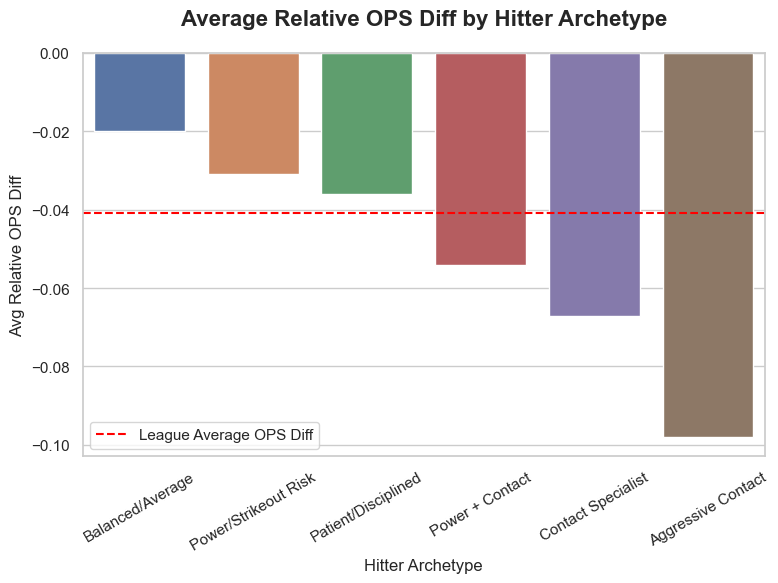

In [265]:
plt.figure(figsize=(8,6))

sns.set_style("whitegrid")

sns.barplot(
    data=archetype_summary,
    x='hitter_archetype',
    y='avg_relative_ops_diff',
    hue='hitter_archetype',
    dodge=False,
    legend=False
)

# Add a horizontal line for league average
league_avg = -0.040801840254
plt.axhline(y=league_avg, color='red', linestyle='--', label='League Average OPS Diff')

plt.title("Average Relative OPS Diff by Hitter Archetype", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Avg Relative OPS Diff")
plt.xlabel("Hitter Archetype")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


In [211]:
## Now lets build postseason experience bins
def postseason_experience(row):
    years = row['postseason_years']

    if years >= 7:
        return 'Veteran Experience (7+ postseasons)'
    elif 4 <= years < 7:
        return 'High Experience (4-6 postseasons)'
    elif 2 <= years < 4:
        return 'Moderate Experience (2-3 postseasons)'
    else:
        return 'Rookie/Debut (1 postseason)'


df['postseason_experience'] = df.apply(postseason_experience, axis=1)

In [250]:
## Summary statistics by postseason experience
# Define order based on years of experience
experience_order = [
    'Rookie/Debut (1 postseason)',
    'Moderate Experience (2-3 postseasons)',
    'High Experience (4-6 postseasons)',
    'Veteran Experience (7+ postseasons)'
]

# Group by postseason experience and calculate summary stats
experience_summary = (
    df.groupby('postseason_experience')
      .agg(
          players=('relative_ops_diff', 'count'),
          avg_relative_ops_diff=('relative_ops_diff', 'mean'),
          std_relative_ops_diff=('relative_ops_diff', 'std'),
          avg_OPS_reg=('OPS_reg', 'mean'),
          avg_OPS_post=('OPS_post', 'mean')
      )
      .round(3)
      .reset_index()
)

# Reorder rows
experience_summary['postseason_experience'] = pd.Categorical(experience_summary['postseason_experience'], categories = experience_order, ordered=True)

experience_summary = experience_summary.sort_values('postseason_experience').reset_index(drop=True)

experience_summary


,postseason_experience,players,avg_relative_ops_diff,std_relative_ops_diff,avg_OPS_reg,avg_OPS_post
0,Rookie/Debut (1 postseason),34,0.021,0.163,0.765,0.746
1,Moderate Experience (2-3 postseasons),133,-0.041,0.159,0.773,0.692
2,High Experience (4-6 postseasons),190,-0.047,0.137,0.787,0.699
3,Veteran Experience (7+ postseasons),60,-0.025,0.108,0.817,0.751


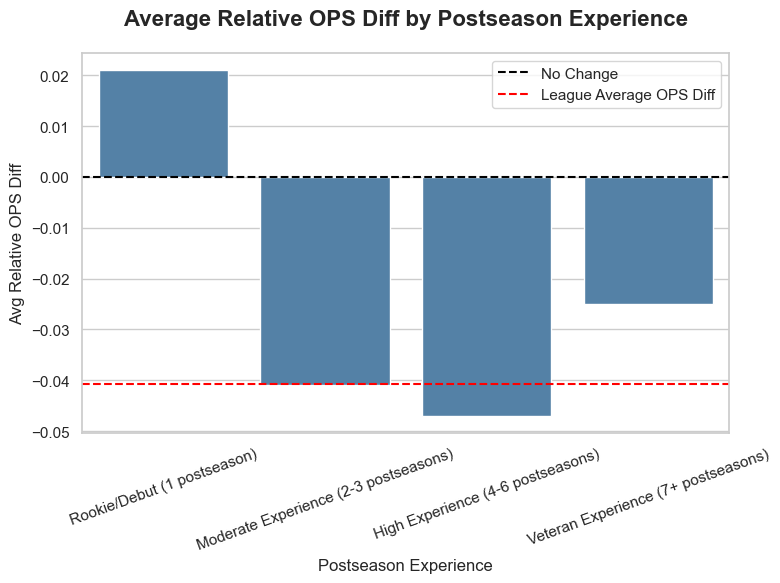

In [266]:
# Set plot style
sns.set_style("whitegrid")

plt.figure(figsize=(8,6))

# Barplot for average relative OPS diff by experience
sns.barplot(
    data=experience_summary,
    x='postseason_experience',
    y='avg_relative_ops_diff',
    color='steelblue'
)

# Add a horizontal line at zero for reference
plt.axhline(y=0, color='black', linestyle='--', label='No Change')

# Add a horizontal line for league average relative OPS (example: 0.0408)
plt.axhline(y=-0.040801840254, color='red', linestyle='--', label='League Average OPS Diff')

# Titles and labels
plt.title("Average Relative OPS Diff by Postseason Experience", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Avg Relative OPS Diff", fontsize=12)
plt.xlabel("Postseason Experience", fontsize=12)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [228]:
## Which hitter types thrive most at different experience levels?
# Define order based on years of experience
experience_order = [
    'Rookie/Debut (1 postseason)',
    'Moderate Experience (2-3 postseasons)',
    'High Experience (4-6 postseasons)',
    'Veteran Experience (7+ postseasons)'
]
# Group by archetype and experience, compute mean relative OPS diff
archetype_plus_experience = df.groupby(['hitter_archetype', 'postseason_experience'])['relative_ops_diff'].mean().unstack().round(3)

# Reorder the columns according to experience_order
archetype_plus_experience = archetype_plus_experience[experience_order]

archetype_plus_experience

postseason_experience,Rookie/Debut (1 postseason),Moderate Experience (2-3 postseasons),High Experience (4-6 postseasons),Veteran Experience (7+ postseasons)
hitter_archetype,,,,
Aggressive Contact,-0.004,-0.170,-0.086,-0.016
Balanced/Average,0.060,-0.041,-0.018,-0.028
Contact Specialist,-0.034,-0.048,-0.095,-0.033
Patient/Disciplined,-0.057,0.017,-0.082,-0.031
Power + Contact,-0.054,-0.002,-0.076,-0.035
Power/Strikeout Risk,0.057,-0.058,-0.030,-0.006


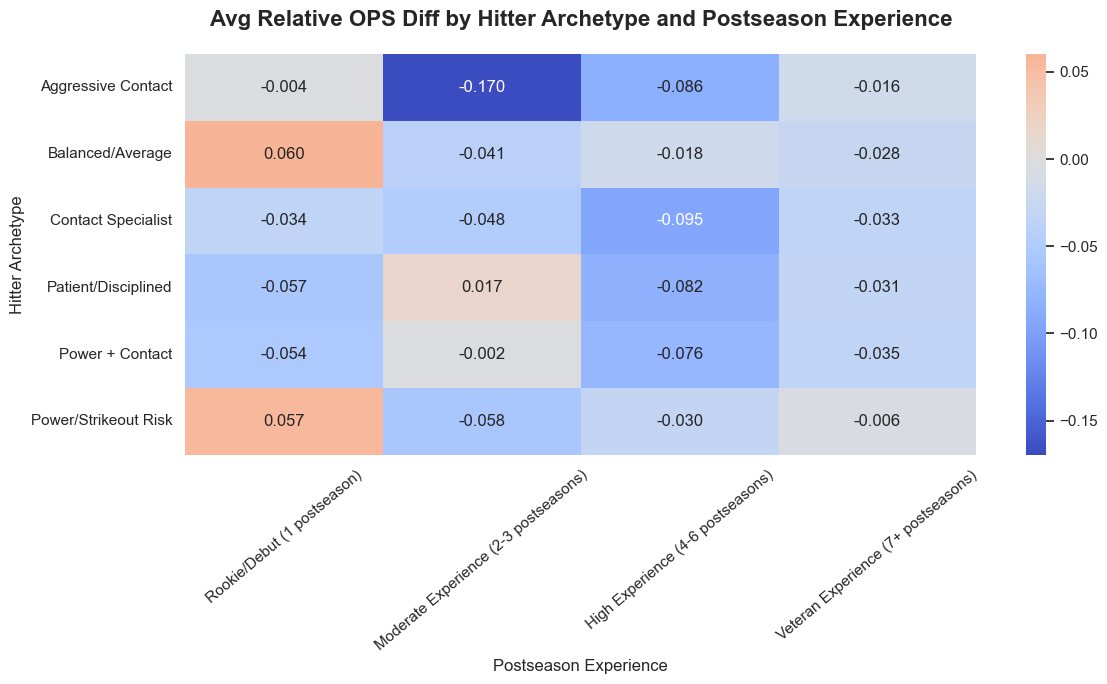

In [220]:
# Set figure size
plt.figure(figsize=(12,7))

# Create heatmap
sns.heatmap(
    archetype_plus_experience, # rows: hitter archetype, columns: experience, values: avg relative OPS diff
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Avg Relative OPS Diff by Hitter Archetype and Postseason Experience", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Postseason Experience", fontsize=12)
plt.ylabel("Hitter Archetype", fontsize=12)
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [216]:
## Bring over postseason performance category logic
def performance_category(row):
    diff = row['relative_ops_diff']

    p75 = df['relative_ops_diff'].quantile(0.75)  # Top 25%
    p50 = df['relative_ops_diff'].quantile(0.50)  # Median
    p25 = df['relative_ops_diff'].quantile(0.25)  # Bottom 25%

    if diff >= p75:
        return 'Elite Performer'
    elif diff >= p50:
        return 'Above Average'
    elif diff >= p25:
        return 'Below Average'
    else:
        return 'Underperformer'

df['performance_category'] = df.apply(performance_category, axis=1)

In [217]:
## Performance categories / hitter archetypes
performance_order = [
    'Underperformer',
    'Below Average',
    'Above Average',
    'Elite Performer'
]

perf_summary = df.groupby(['hitter_archetype', 'performance_category']).size().unstack(fill_value=0)

# Reorder rows
perf_summary = perf_summary[performance_order]

perf_summary

performance_category,Underperformer,Below Average,Above Average,Elite Performer
hitter_archetype,,,,
Aggressive Contact,5,5,2,3
Balanced/Average,30,36,48,42
Contact Specialist,16,12,15,8
Patient/Disciplined,16,15,8,18
Power + Contact,10,13,14,4
Power/Strikeout Risk,27,23,17,30


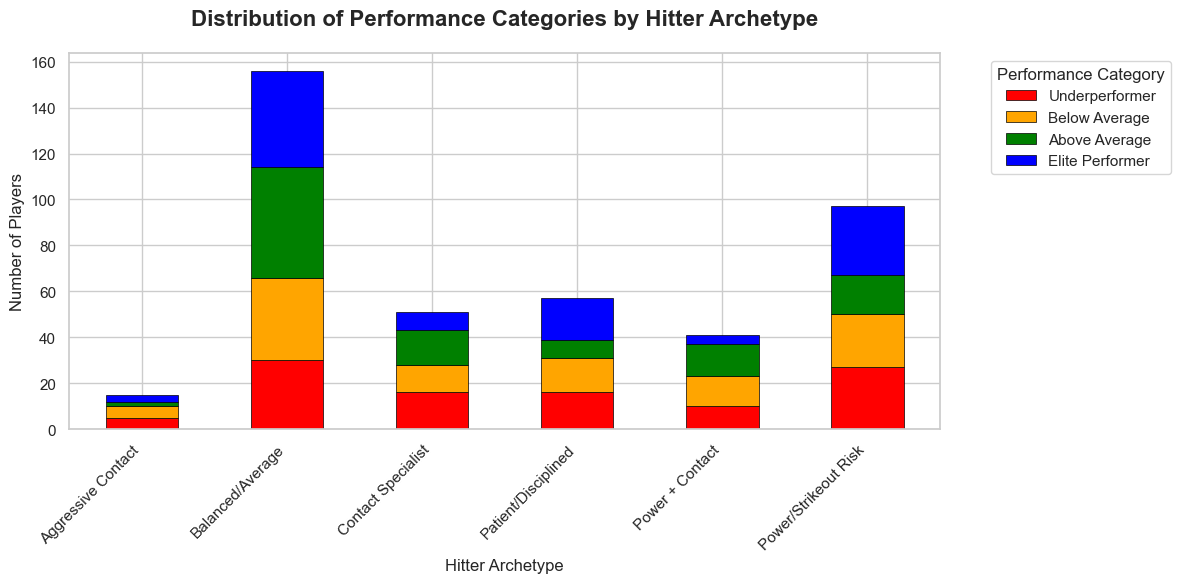

In [230]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bar chart with color-coded performance
colors = ['red', 'orange', 'green', 'blue']
perf_summary.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Titles and labels
plt.title("Distribution of Performance Categories by Hitter Archetype", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Number of Players", fontsize=12)
plt.xlabel("Hitter Archetype", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Performance Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()